2.1 理论计算题：非线性激活函数的重要性

【1. 线性激活 MLP 等价证明】

维度设置:
  输入维度: 3
  隐藏层维度: 4
  输出维度: 2

参数形状:
  W1: (4, 3), b1: (4, 1)
  W2: (2, 4), b2: (2, 1)
  x: (3, 1)

原始双层网络计算:
h = W1 @ x + b1 -> h 形状: (4, 1)
o = W2 @ h + b2 -> o 形状: (2, 1)
原始网络输出 o:
[3.32645648 1.13682022]

代数推导:
o = W2 @ (W1 @ x + b1) + b2
  = (W2 @ W1) @ x + W2 @ b1 + b2
  = W' @ x + b'

其中:
  W' = W2 @ W1
  b' = W2 @ b1 + b2

等价单层网络参数:
  W' 形状: (2, 3)
  b' 形状: (2, 1)

等价网络输出 o':
[3.32645648 1.13682022]

两者是否相等: True
最大差异: 4.44e-16

维度验证:
W2 ((2, 4)) @ W1 ((4, 3)) = W' ((2, 3)) ✓
W' ((2, 3)) @ x ((3, 1)) = ([[ 2.35676166]
 [-0.44534494]].shape) ✓
最终输出维度: 2 ✓

数值验证示例:
简化模型:
W1_test:
[[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 1.]]
b1_test: [0.1 0.2 0.3 0.4]
W2_test:
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]]
b2_test: [0.5 0.6]
x_test: [2 3 1]

原始网络输出: [5.9 8.2]
等价网络输出: [5.9 8.2]
验证相等: True

【2. 激活函数导数关系】

Sigmoid 函数及其导数关系验证:
       x |         σ(x) |        σ'(x) |       σ(x)(1-σ(x)) |     相等
-----------------------------------------------------

C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\2605281236.py:213: UserWarning: Glyph 26041 (\

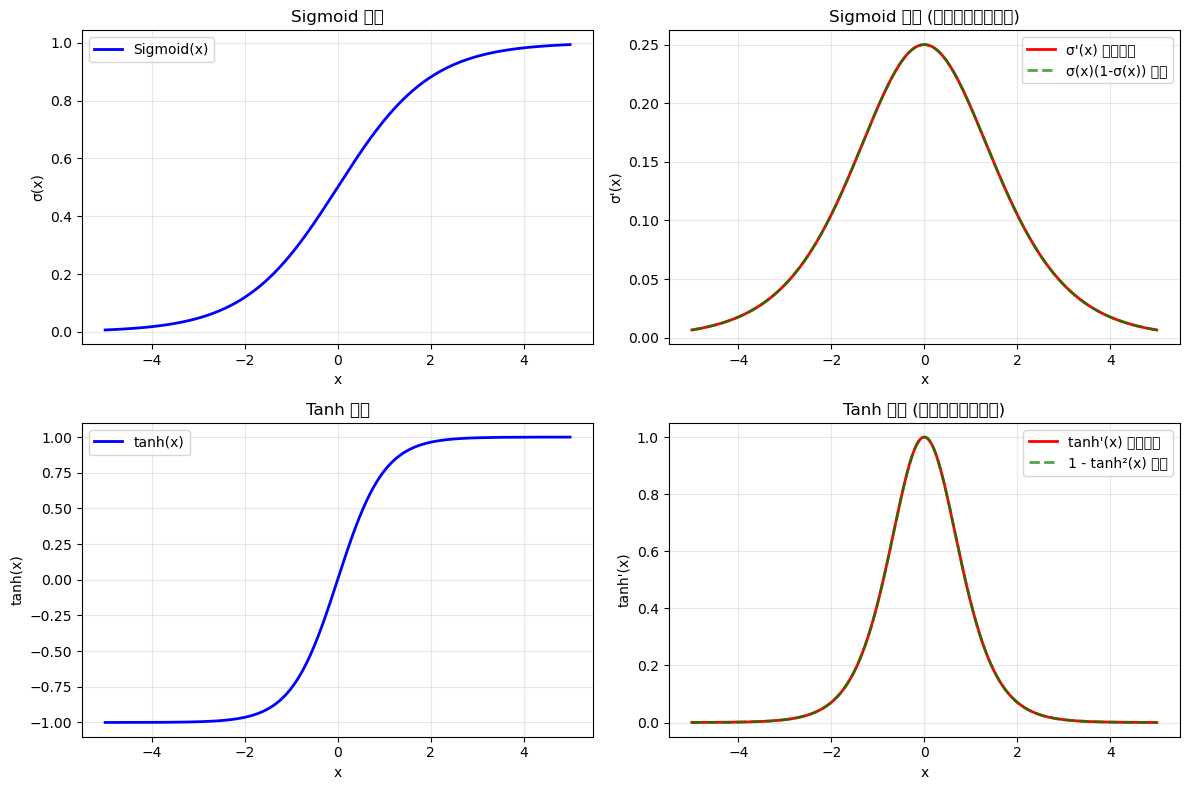


结论总结:
1. 线性激活MLP等价性:
   - 无激活函数的单隐藏层MLP等价于单层线性网络
   - 等价权重: W' = W2 @ W1
   - 等价偏置: b' = W2 @ b1 + b2
   - 无法表示非线性函数，表达能力受限

2. 激活函数导数关系:
   - Sigmoid导数: σ'(x) = σ(x)(1-σ(x))
   - Tanh导数: tanh'(x) = 1 - tanh²(x)
   - 这种形式使得反向传播计算更高效


In [ ]:
2.1
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("2.1 理论计算题：非线性激活函数的重要性")
print("=" * 70)

# 第一部分：线性激活 MLP 等价于单层网络
print("\n【1. 线性激活 MLP 等价证明】")

# 定义维度
np.random.seed(42)
input_dim = 3    # 输入维度
hidden_dim = 4   # 隐藏层维度
output_dim = 2   # 输出维度

print(f"\n维度设置:")
print(f"  输入维度: {input_dim}")
print(f"  隐藏层维度: {hidden_dim}")
print(f"  输出维度: {output_dim}")

# 参数初始化
# 使用标准的前向传播定义: h = W1 @ x + b1
# 其中 x 是列向量 (input_dim, 1)
# W1: (hidden_dim, input_dim)
# b1: (hidden_dim, 1)
# h: (hidden_dim, 1)

W1 = np.random.randn(hidden_dim, input_dim)   # (4, 3)
b1 = np.random.randn(hidden_dim, 1)           # (4, 1)
W2 = np.random.randn(output_dim, hidden_dim)  # (2, 4)
b2 = np.random.randn(output_dim, 1)           # (2, 1)

# 输入 x (列向量)
x = np.random.randn(input_dim, 1)  # (3, 1)

print(f"\n参数形状:")
print(f"  W1: {W1.shape}, b1: {b1.shape}")
print(f"  W2: {W2.shape}, b2: {b2.shape}")
print(f"  x: {x.shape}")

# 原始双层网络
print("\n" + "=" * 50)
print("原始双层网络计算:")
print("=" * 50)

# 隐藏层: h = W1 @ x + b1
h = W1 @ x + b1
print(f"h = W1 @ x + b1 -> h 形状: {h.shape}")

# 输出层: o = W2 @ h + b2
o = W2 @ h + b2
print(f"o = W2 @ h + b2 -> o 形状: {o.shape}")
print(f"原始网络输出 o:\n{o.flatten()}")

# 等价单层网络推导
print("\n" + "=" * 50)
print("代数推导:")
print("=" * 50)
print("o = W2 @ (W1 @ x + b1) + b2")
print("  = (W2 @ W1) @ x + W2 @ b1 + b2")
print("  = W' @ x + b'")
print("\n其中:")
print("  W' = W2 @ W1")
print("  b' = W2 @ b1 + b2")

# 计算等价参数
W_prime = W2 @ W1   # (2,4) @ (4,3) = (2,3)
b_prime = W2 @ b1 + b2  # (2,1)

print(f"\n等价单层网络参数:")
print(f"  W' 形状: {W_prime.shape}")
print(f"  b' 形状: {b_prime.shape}")

# 使用等价网络计算
o_equivalent = W_prime @ x + b_prime
print(f"\n等价网络输出 o':\n{o_equivalent.flatten()}")

# 验证相等性
print(f"\n两者是否相等: {np.allclose(o, o_equivalent)}")
print(f"最大差异: {np.max(np.abs(o - o_equivalent)):.2e}")

# 验证维度
print("\n" + "=" * 50)
print("维度验证:")
print("=" * 50)
print(f"W2 ({W2.shape}) @ W1 ({W1.shape}) = W' ({W_prime.shape}) ✓")
print(f"W' ({W_prime.shape}) @ x ({x.shape}) = ({W_prime @ x}.shape) ✓")
print(f"最终输出维度: {output_dim} ✓")

# 数值验证 - 使用具体数值
print("\n" + "=" * 50)
print("数值验证示例:")
print("=" * 50)

# 使用简单数值
W1_test = np.array([[1, 0, 1],
                    [0, 1, 0],
                    [1, 0, 0],
                    [0, 1, 1]]).astype(float)
b1_test = np.array([[0.1], [0.2], [0.3], [0.4]])
W2_test = np.array([[1, 0, 1, 0],
                    [0, 1, 0, 1]]).astype(float)
b2_test = np.array([[0.5], [0.6]])
x_test = np.array([[2], [3], [1]])

print("简化模型:")
print(f"W1_test:\n{W1_test}")
print(f"b1_test: {b1_test.flatten()}")
print(f"W2_test:\n{W2_test}")
print(f"b2_test: {b2_test.flatten()}")
print(f"x_test: {x_test.flatten()}")

# 原始网络
h_test = W1_test @ x_test + b1_test
o_test = W2_test @ h_test + b2_test
print(f"\n原始网络输出: {o_test.flatten()}")

# 等价网络
W_prime_test = W2_test @ W1_test
b_prime_test = W2_test @ b1_test + b2_test
o_equiv_test = W_prime_test @ x_test + b_prime_test
print(f"等价网络输出: {o_equiv_test.flatten()}")
print(f"验证相等: {np.allclose(o_test, o_equiv_test)}")

# 第二部分：Sigmoid 和 Tanh 导数关系
print("\n" + "=" * 70)
print("【2. 激活函数导数关系】")
print("=" * 70)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t**2

# 测试不同 x 值
x_vals = np.array([-10, -2, -1, 0, 1, 2, 10])

print("\nSigmoid 函数及其导数关系验证:")
print(f"{'x':>8} | {'σ(x)':>12} | {'σ\'(x)':>12} | {'σ(x)(1-σ(x))':>18} | {'相等':>6}")
print("-" * 65)
for x in x_vals:
    s = sigmoid(x)
    s_deriv = sigmoid_derivative(x)
    s_rel = s * (1 - s)
    match = "✓" if np.isclose(s_deriv, s_rel) else "✗"
    print(f"{x:8.2f} | {s:12.6f} | {s_deriv:12.6f} | {s_rel:18.6f} | {match:>6}")

print("\nTanh 函数及其导数关系验证:")
print(f"{'x':>8} | {'tanh(x)':>12} | {'tanh\'(x)':>12} | {'1-tanh²(x)':>16} | {'相等':>6}")
print("-" * 65)
for x in x_vals:
    t = tanh(x)
    t_deriv = tanh_derivative(x)
    t_rel = 1 - t**2
    match = "✓" if np.isclose(t_deriv, t_rel) else "✗"
    print(f"{x:8.2f} | {t:12.6f} | {t_deriv:12.6f} | {t_rel:16.6f} | {match:>6}")

# 绘制函数图像
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x_plot = np.linspace(-5, 5, 1000)

# Sigmoid 函数
axes[0, 0].plot(x_plot, sigmoid(x_plot), 'b-', linewidth=2, label='Sigmoid(x)')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('σ(x)')
axes[0, 0].set_title('Sigmoid 函数')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Sigmoid 导数
s_plot = sigmoid(x_plot)
s_deriv_direct = sigmoid_derivative(x_plot)
s_deriv_formula = s_plot * (1 - s_plot)
axes[0, 1].plot(x_plot, s_deriv_direct, 'r-', linewidth=2, label="σ'(x) 直接计算")
axes[0, 1].plot(x_plot, s_deriv_formula, 'g--', linewidth=2, label='σ(x)(1-σ(x)) 公式', alpha=0.7)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel("σ'(x)")
axes[0, 1].set_title("Sigmoid 导数 (两种方法完全重合)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Tanh 函数
axes[1, 0].plot(x_plot, tanh(x_plot), 'b-', linewidth=2, label='tanh(x)')
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('tanh(x)')
axes[1, 0].set_title('Tanh 函数')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Tanh 导数
t_plot = tanh(x_plot)
t_deriv_direct = tanh_derivative(x_plot)
t_deriv_formula = 1 - t_plot**2
axes[1, 1].plot(x_plot, t_deriv_direct, 'r-', linewidth=2, label="tanh'(x) 直接计算")
axes[1, 1].plot(x_plot, t_deriv_formula, 'g--', linewidth=2, label='1 - tanh²(x) 公式', alpha=0.7)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel("tanh'(x)")
axes[1, 1].set_title("Tanh 导数 (两种方法完全重合)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("结论总结:")
print("=" * 70)
print("1. 线性激活MLP等价性:")
print("   - 无激活函数的单隐藏层MLP等价于单层线性网络")
print("   - 等价权重: W' = W2 @ W1")
print("   - 等价偏置: b' = W2 @ b1 + b2")
print("   - 无法表示非线性函数，表达能力受限")
print("\n2. 激活函数导数关系:")
print("   - Sigmoid导数: σ'(x) = σ(x)(1-σ(x))")
print("   - Tanh导数: tanh'(x) = 1 - tanh²(x)")
print("   - 这种形式使得反向传播计算更高效")
print("=" * 70)

加载 Fashion-MNIST...
训练集大小: 56000, 测试集大小: 14000
特征维度: 784, 类别数: 10

开始训练...
Epoch   0, Loss: 0.5054, Test Acc: 0.8551
Epoch   5, Loss: 0.2649, Test Acc: 0.8879
Epoch  10, Loss: 0.2023, Test Acc: 0.8841
Epoch  15, Loss: 0.1589, Test Acc: 0.8941

最终测试准确率: 0.8897


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\945222576.py:160: UserWarning: Glyph 32447 (\N{CJK 

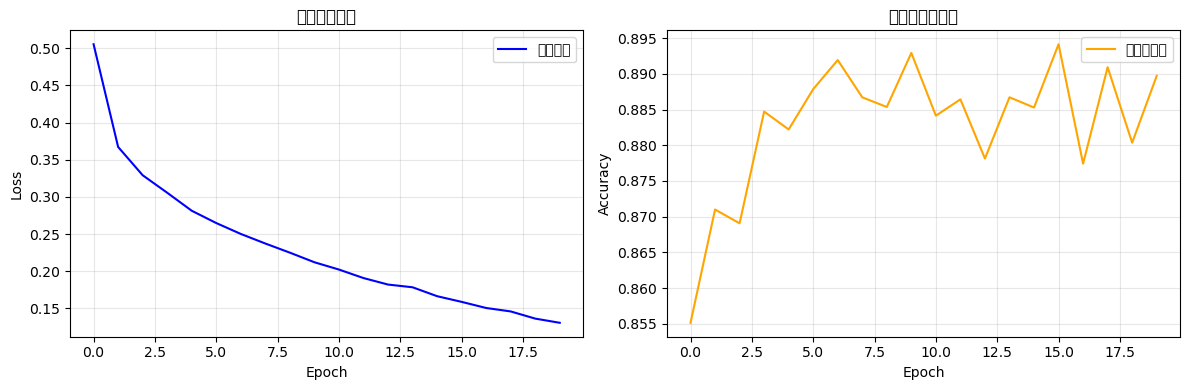


各类别准确率:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.82      0.83      1394
     Trouser       0.98      0.99      0.98      1402
    Pullover       0.80      0.83      0.82      1407
       Dress       0.92      0.89      0.90      1449
        Coat       0.82      0.82      0.82      1357
      Sandal       0.95      0.97      0.96      1449
       Shirt       0.73      0.72      0.72      1407
     Sneaker       0.95      0.94      0.94      1359
         Bag       0.97      0.97      0.97      1342
  Ankle boot       0.95      0.95      0.95      1434

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



In [ ]:
2.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子
np.random.seed(42)

# 加载 Fashion-MNIST（使用 sklearn 获取数据）
print("加载 Fashion-MNIST...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32)
y = y.astype(np.int32)

# 归一化到 [0,1]
X /= 255.0

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化（有助于训练）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
print(f"特征维度: {X_train.shape[1]}, 类别数: {len(np.unique(y))}")

# 参数初始化
input_size = X_train.shape[1]  # 784
hidden_size = 128
output_size = 10

# 正态分布初始化
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

# ReLU 激活函数
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Softmax 函数
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# 交叉熵损失（不需要 one-hot，直接使用标签）
def cross_entropy_loss(Y_pred, y_true):
    # Y_pred: (batch, 10), y_true: (batch,)
    n = Y_pred.shape[0]
    log_likelihood = -np.log(Y_pred[np.arange(n), y_true] + 1e-8)
    return np.mean(log_likelihood)

# One-hot 编码（用于梯度计算）
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

# 训练参数
batch_size = 64
lr = 0.1
epochs = 20

train_losses = []
test_accs = []

print("\n开始训练...")
for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    epoch_loss = 0
    num_batches = 0
    
    # Mini-batch SGD
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # ---------- 前向传播 ----------
        # 隐藏层
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)
        # 输出层
        Z2 = A1 @ W2 + b2
        A2 = softmax(Z2)
        
        # 计算损失
        loss = cross_entropy_loss(A2, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # ---------- 反向传播 ----------
        batch_n = X_batch.shape[0]
        
        # 将 y_batch 转为 one-hot
        y_onehot = one_hot(y_batch, output_size)
        
        # 输出层梯度
        dZ2 = A2 - y_onehot                     # (batch, 10)
        dW2 = (A1.T @ dZ2) / batch_n
        db2 = np.mean(dZ2, axis=0, keepdims=True)
        
        # 隐藏层梯度
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = (X_batch.T @ dZ1) / batch_n
        db1 = np.mean(dZ1, axis=0, keepdims=True)
        
        # ---------- 参数更新 ----------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # 测试集评估
    Z1_test = X_test @ W1 + b1
    A1_test = relu(Z1_test)
    Z2_test = A1_test @ W2 + b2
    A2_test = softmax(Z2_test)
    
    y_pred = np.argmax(A2_test, axis=1)
    acc = np.mean(y_pred == y_test)
    test_accs.append(acc)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

print(f"\n最终测试准确率: {test_accs[-1]:.4f}")

# 绘图
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失曲线')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='测试准确率', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('测试准确率曲线')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印各类别准确率
from sklearn.metrics import classification_report
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("\n各类别准确率:")
print(classification_report(y_test, y_pred, target_names=class_names))

3.1 理论计算题：过拟合与欠拟合、K折交叉验证

【1. 过拟合与欠拟合】
--------------------------------------------------


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1415436545.py:67: UserWarning: Glyph 24046 (\N{CJK 

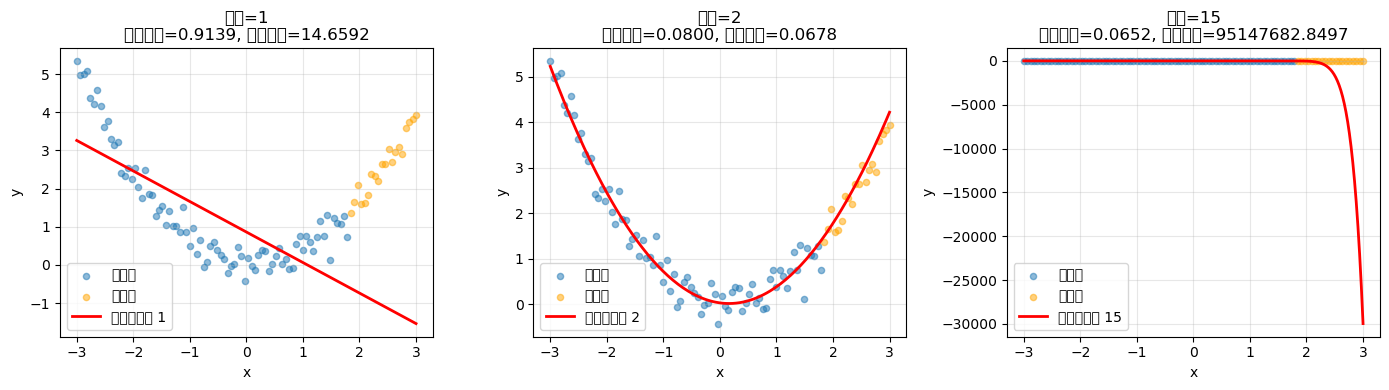


模型复杂度与误差关系:
多项式次数        | 训练误差         | 验证误差         | 状态             
-------------------------------------------------------
1            | 0.9139       | 14.6592      | 欠拟合            
2            | 0.0800       | 0.0678       | 正常             
15           | 0.0652       | 95147682.8497 | 过拟合            

结论:
  - 欠拟合: 模型过于简单，训练误差和验证误差都高
  - 过拟合: 模型过于复杂，训练误差极低但验证误差很高
  - 缓解过拟合方法: 增加数据量、降低模型复杂度、正则化(L1/L2)、早停、Dropout等

【2. K折交叉验证】

K=5 折交叉验证算法步骤:
1. 将数据集随机划分为 K 个大小相等的子集
2. 对每个折 fold i = 1 到 K:
   - 将第 i 折作为验证集
   - 其余 K-1 折合并作为训练集
   - 在训练集上训练模型
   - 在验证集上评估模型性能
3. 计算 K 次评估结果的平均值作为最终性能指标

K折交叉验证演示
Fold 1: 训练集大小=80, 验证集大小=20, MSE=0.008728
Fold 2: 训练集大小=80, 验证集大小=20, MSE=0.006978
Fold 3: 训练集大小=80, 验证集大小=20, MSE=0.012538
Fold 4: 训练集大小=80, 验证集大小=20, MSE=0.012416
Fold 5: 训练集大小=80, 验证集大小=20, MSE=0.007479

平均 MSE: 0.009628 (+/- 0.002395)

K折交叉验证优点:
  - 充分利用有限数据（每个样本都被用作验证一次）
  - 减少评估结果的方差
  - 适用于小数据集和模型选择


In [9]:
3.1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("=" * 70)
print("3.1 理论计算题：过拟合与欠拟合、K折交叉验证")
print("=" * 70)

# 第一部分：过拟合与欠拟合
print("\n【1. 过拟合与欠拟合】")
print("-" * 50)

# 生成示例数据
np.random.seed(42)
n_samples = 100
X_poly = np.linspace(-3, 3, n_samples).reshape(-1, 1)
y_true = 0.5 * X_poly.ravel()**2 - 0.2 * X_poly.ravel() + 0.1
y = y_true + np.random.normal(0, 0.3, n_samples)

# 划分训练集和验证集
X_train_poly, X_val_poly = X_poly[:80], X_poly[80:]
y_train_poly, y_val_poly = y[:80], y[80:]

# 不同复杂度的模型
degrees = [1, 2, 15]
train_errors = []
val_errors = []

plt.figure(figsize=(14, 4))

for idx, degree in enumerate(degrees):
    # 构造多项式特征
    X_train_poly_features = np.column_stack([X_train_poly.ravel()**d for d in range(degree+1)])
    X_val_poly_features = np.column_stack([X_val_poly.ravel()**d for d in range(degree+1)])
    
    # 训练模型
    model = LinearRegression()
    model.fit(X_train_poly_features, y_train_poly)
    
    # 预测
    y_train_pred = model.predict(X_train_poly_features)
    y_val_pred = model.predict(X_val_poly_features)
    
    train_mse = mean_squared_error(y_train_poly, y_train_pred)
    val_mse = mean_squared_error(y_val_poly, y_val_pred)
    train_errors.append(train_mse)
    val_errors.append(val_mse)
    
    # 绘图
    plt.subplot(1, 3, idx+1)
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    X_plot_features = np.column_stack([X_plot.ravel()**d for d in range(degree+1)])
    y_plot_pred = model.predict(X_plot_features)
    
    plt.scatter(X_train_poly, y_train_poly, alpha=0.5, s=20, label='训练集')
    plt.scatter(X_val_poly, y_val_poly, alpha=0.5, s=20, label='验证集', color='orange')
    plt.plot(X_plot, y_plot_pred, 'r-', linewidth=2, label=f'多项式次数 {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'次数={degree}\n训练误差={train_mse:.4f}, 验证误差={val_mse:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n模型复杂度与误差关系:")
print(f"{'多项式次数':<12} | {'训练误差':<12} | {'验证误差':<12} | {'状态':<15}")
print("-" * 55)
states = ["欠拟合", "正常", "过拟合"]
for i, degree in enumerate(degrees):
    print(f"{degree:<12} | {train_errors[i]:<12.4f} | {val_errors[i]:<12.4f} | {states[i]:<15}")

print("\n结论:")
print("  - 欠拟合: 模型过于简单，训练误差和验证误差都高")
print("  - 过拟合: 模型过于复杂，训练误差极低但验证误差很高")
print("  - 缓解过拟合方法: 增加数据量、降低模型复杂度、正则化(L1/L2)、早停、Dropout等")

# 第二部分：K折交叉验证
print("\n" + "=" * 70)
print("【2. K折交叉验证】")
print("=" * 70)

# 生成数据
np.random.seed(42)
X_kfold = np.random.randn(100, 1)
y_kfold = 2 * X_kfold.ravel() + np.random.normal(0, 0.1, 100)

# 实现 K 折交叉验证
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

print(f"\nK={k} 折交叉验证算法步骤:")
print("=" * 50)
print("1. 将数据集随机划分为 K 个大小相等的子集")
print("2. 对每个折 fold i = 1 到 K:")
print("   - 将第 i 折作为验证集")
print("   - 其余 K-1 折合并作为训练集")
print("   - 在训练集上训练模型")
print("   - 在验证集上评估模型性能")
print("3. 计算 K 次评估结果的平均值作为最终性能指标")

# 演示 K 折交叉验证
print("\n" + "=" * 50)
print("K折交叉验证演示")
print("=" * 50)

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_kfold)):
    X_train_fold, X_val_fold = X_kfold[train_idx], X_kfold[val_idx]
    y_train_fold, y_val_fold = y_kfold[train_idx], y_kfold[val_idx]
    
    # 训练线性回归模型
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    # 评估
    y_pred_fold = model.predict(X_val_fold)
    mse = mean_squared_error(y_val_fold, y_pred_fold)
    fold_scores.append(mse)
    
    print(f"Fold {fold+1}: 训练集大小={len(train_idx)}, 验证集大小={len(val_idx)}, MSE={mse:.6f}")

print(f"\n平均 MSE: {np.mean(fold_scores):.6f} (+/- {np.std(fold_scores):.6f})")

print("\n" + "=" * 70)
print("K折交叉验证优点:")
print("  - 充分利用有限数据（每个样本都被用作验证一次）")
print("  - 减少评估结果的方差")
print("  - 适用于小数据集和模型选择")
print("=" * 70)

加载 Fashion-MNIST...
训练集: 1400, 验证集: 600
特征维度: 784
开始对比实验

>>> No Reg (Overfitting)
Epoch   0, Train Loss: 1.6182, Val Loss: 1.0366, Val Acc: 0.6183
Epoch  10, Train Loss: 0.2595, Val Loss: 0.5171, Val Acc: 0.8267
Epoch  20, Train Loss: 0.1110, Val Loss: 0.5869, Val Acc: 0.8233
Epoch  30, Train Loss: 0.0556, Val Loss: 0.6804, Val Acc: 0.8317
Epoch  40, Train Loss: 0.0250, Val Loss: 0.7195, Val Acc: 0.8333

>>> L2 Regularization
Epoch   0, Train Loss: 1.8263, Val Loss: 1.2363, Val Acc: 0.6433
Epoch  10, Train Loss: 0.5433, Val Loss: 0.7333, Val Acc: 0.8317
Epoch  20, Train Loss: 0.4471, Val Loss: 0.7444, Val Acc: 0.8300
Epoch  30, Train Loss: 0.4122, Val Loss: 0.7644, Val Acc: 0.8083
Epoch  40, Train Loss: 0.3960, Val Loss: 0.8080, Val Acc: 0.8017

>>> Dropout
Epoch   0, Train Loss: 1.4389, Val Loss: 0.9385, Val Acc: 0.6567
Epoch  10, Train Loss: 0.2963, Val Loss: 0.5760, Val Acc: 0.8350
Epoch  20, Train Loss: 0.1646, Val Loss: 0.6508, Val Acc: 0.8350
Epoch  30, Train Loss: 0.1116, Val L

C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3696772212.py:203: UserWarning: Glyph 27604 (\

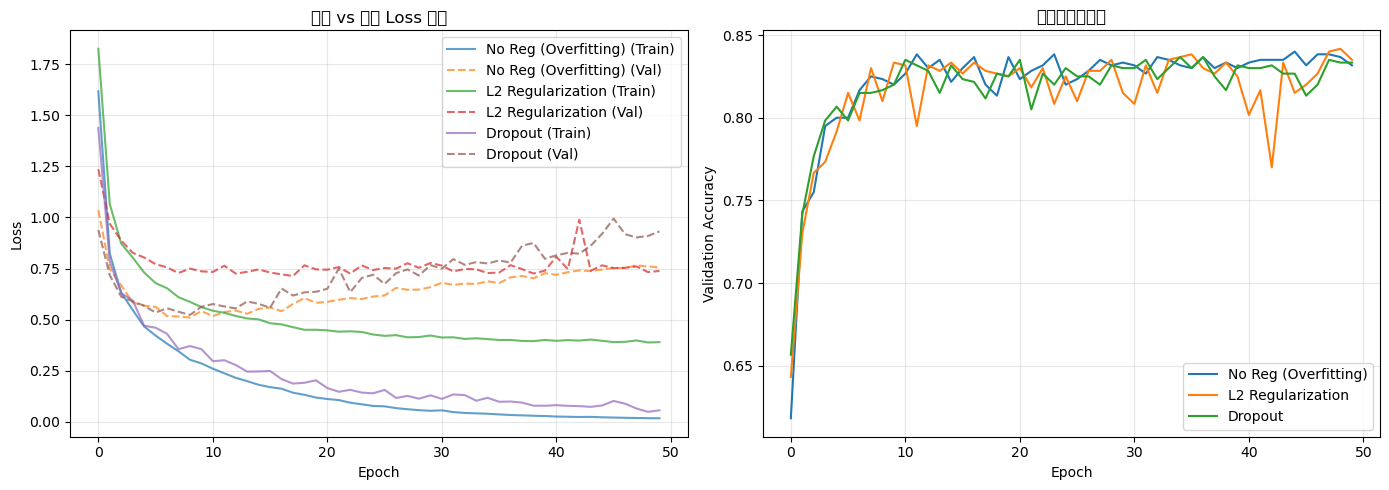


最终验证准确率对比
No Reg (Overfitting)     : 0.8317
L2 Regularization        : 0.8350
Dropout                  : 0.8333


In [ ]:
3.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# 加载 Fashion-MNIST（使用较少样本模拟过拟合）
print("加载 Fashion-MNIST...")
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0
y = y.astype(np.int32)

# 只取前 2000 个样本（模拟小数据集，容易过拟合）
X = X[:2000]
y = y[:2000]

# 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"训练集: {X_train.shape[0]}, 验证集: {X_val.shape[0]}")
print(f"特征维度: {X_train.shape[1]}")

# 参数初始化
input_size = X_train.shape[1]
hidden_size = 256  # 较大的隐藏层，容易过拟合
output_size = 10

def init_params():
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

# ReLU 及其导数
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

# Softmax
def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(Y_pred, y_true):
    n = Y_pred.shape[0]
    return -np.mean(np.log(Y_pred[np.arange(n), y_true] + 1e-8))

# One-hot
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

# Dropout 层
def dropout_layer(A, dropout_prob, is_training=True):
    if not is_training or dropout_prob == 0:
        return A
    mask = (np.random.rand(*A.shape) > dropout_prob).astype(float)
    return A * mask / (1 - dropout_prob)

# 训练一个模型
def train_model(W1, b1, W2, b2, X_train, y_train, X_val, y_val,
                l2_lambda=0.0, dropout_prob=0.0, lr=0.1, epochs=50, batch_size=64):
    
    train_losses = []
    val_losses = []
    val_accs = []
    
    for epoch in range(epochs):
        # 打乱数据
        indices = np.random.permutation(X_train.shape[0])
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        num_batches = 0
        
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # 前向传播
            Z1 = X_batch @ W1 + b1
            A1 = relu(Z1)
            A1_dropped = dropout_layer(A1, dropout_prob, is_training=True)
            Z2 = A1_dropped @ W2 + b2
            A2 = softmax(Z2)
            
            loss = cross_entropy_loss(A2, y_batch)
            
            # 添加 L2 正则化项
            if l2_lambda > 0:
                loss += l2_lambda * (np.sum(W1**2) + np.sum(W2**2))
            
            epoch_loss += loss
            num_batches += 1
            
            # 反向传播
            batch_n = X_batch.shape[0]
            y_onehot = one_hot(y_batch, output_size)
            
            dZ2 = A2 - y_onehot
            dW2 = (A1_dropped.T @ dZ2) / batch_n + 2 * l2_lambda * W2
            db2 = np.mean(dZ2, axis=0, keepdims=True)
            
            dA1 = dZ2 @ W2.T
            dA1 = dA1 * (1 / (1 - dropout_prob) if dropout_prob > 0 else 1)  # Dropout 反向缩放
            dZ1 = dA1 * relu_derivative(Z1)
            dW1 = (X_batch.T @ dZ1) / batch_n + 2 * l2_lambda * W1
            db1 = np.mean(dZ1, axis=0, keepdims=True)
            
            # 参数更新
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1
        
        avg_train_loss = epoch_loss / num_batches
        train_losses.append(avg_train_loss)
        
        # 验证
        Z1_val = X_val @ W1 + b1
        A1_val = relu(Z1_val)
        Z2_val = A1_val @ W2 + b2
        A2_val = softmax(Z2_val)
        
        val_loss = cross_entropy_loss(A2_val, y_val)
        if l2_lambda > 0:
            val_loss += l2_lambda * (np.sum(W1**2) + np.sum(W2**2))
        val_losses.append(val_loss)
        
        y_pred_val = np.argmax(A2_val, axis=1)
        val_acc = np.mean(y_pred_val == y_val)
        val_accs.append(val_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return train_losses, val_losses, val_accs

# 三种配置实验
configs = [
    ("No Reg (Overfitting)", 0.0, 0.0),
    ("L2 Regularization", 0.01, 0.0),
    ("Dropout", 0.0, 0.5)
]

results = {}

print("=" * 60)
print("开始对比实验")
print("=" * 60)

for name, l2_lambda, dropout_prob in configs:
    print(f"\n>>> {name}")
    W1, b1, W2, b2 = init_params()
    train_losses, val_losses, val_accs = train_model(
        W1, b1, W2, b2,
        X_train, y_train, X_val, y_val,
        l2_lambda=l2_lambda,
        dropout_prob=dropout_prob,
        lr=0.1,
        epochs=50,
        batch_size=64
    )
    results[name] = {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_acc': val_accs
    }

# 绘图对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
for name, res in results.items():
    axes[0].plot(res['train_loss'], linestyle='-', label=f'{name} (Train)', alpha=0.7)
    axes[0].plot(res['val_loss'], linestyle='--', label=f'{name} (Val)', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练 vs 验证 Loss 对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 验证准确率
for name, res in results.items():
    axes[1].plot(res['val_acc'], label=name)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('验证准确率对比')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n" + "=" * 60)
print("最终验证准确率对比")
print("=" * 60)
for name, res in results.items():
    final_acc = res['val_acc'][-1]
    print(f"{name:25s}: {final_acc:.4f}")

4.1 理论计算题：梯度消失与梯度爆炸

【1. 梯度消失与梯度爆炸的量化分析】
--------------------------------------------------

情景1: Sigmoid激活 + 标准初始化 (weight_scale=1.0)
第1层梯度范数: 2.05e+01
第5层梯度范数: 4.57e+02
第10层梯度范数: 1.93e+04
第20层梯度范数: 3.40e+07
→ 梯度逐渐趋近于0 (梯度消失)

情景2: Sigmoid激活 + 大初始化 (weight_scale=10.0)
第1层梯度范数: 2.02e+02
第5层梯度范数: 4.88e+07
第10层梯度范数: 1.95e+14
第20层梯度范数: 爆炸 (>1e+10)
→ 梯度急剧增大 (梯度爆炸)

情景3: ReLU激活 + 标准初始化 (weight_scale=1.0)
第1层梯度范数: 7.06e+01
第5层梯度范数: 1.50e+05
第10层梯度范数: 2.02e+09
第20层梯度范数: 6.75e+17
→ 梯度相对稳定 (ReLU缓解梯度消失)

【2. 梯度消失/爆炸可视化】


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 39281 (\N{CJK UNIFIED IDEOGRAPH-9971}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 23548 (\N{CJK UNIFIED IDEOGRAPH-5BFC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\4188937648.py:127: UserWarning: Glyph 33268 (\

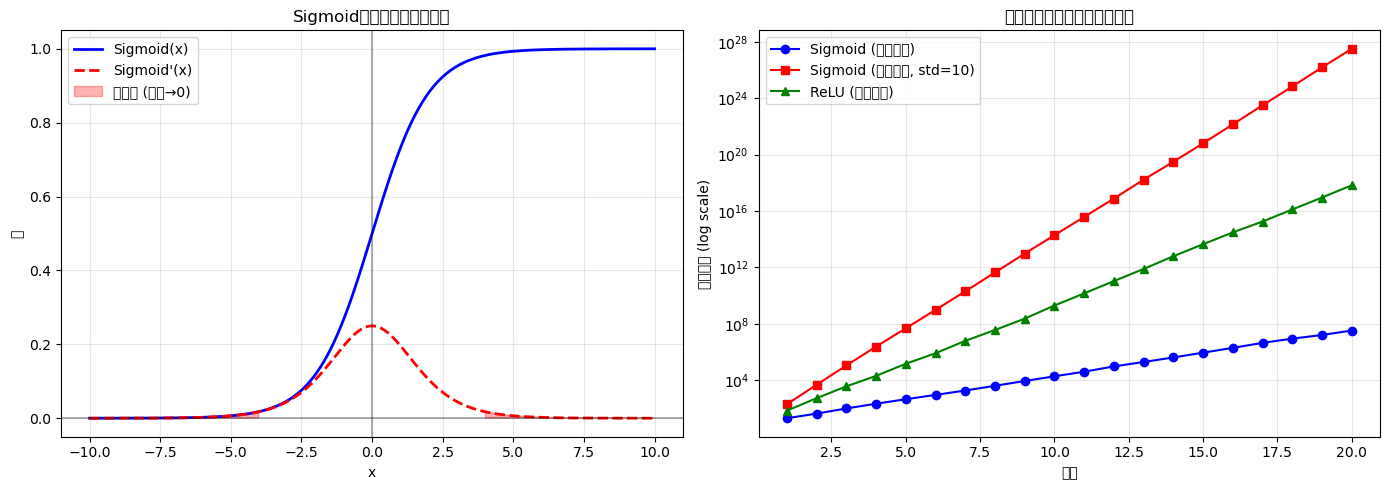


【3. 数学分析】

梯度消失的数学原因:
  - 对于 Sigmoid: |σ'(x)| ≤ 0.25
  - 深层网络梯度: ∂L/∂h¹ = (∂L/∂hᵈ) · ∏ᵢ₌₁ᵈ⁻¹ (diag(σ'(zⁱ))·Wⁱ)
  - 当 ∏ |σ'(z)| < 1 时，梯度指数级衰减 → 消失

梯度爆炸的数学原因:
  - 当权重 ||W|| > 1 且激活函数导数不约束时，梯度指数级增长
  - 例如: 权重初始化过大 或 使用ReLU时未配合合适初始化

ReLU缓解梯度消失的原因:
  - ReLU'(x) = 1 (当 x>0), 0 (当 x≤0)
  - 正半轴梯度为1，不会压缩梯度
  - 但需要注意: 负半轴可能导致神经元死亡
  - 配合Xavier/He初始化可获得稳定梯度

结论:
  1. 梯度消失: 激活函数导数 < 1 且网络很深
  2. 梯度爆炸: 权重初始值过大
  3. 缓解方法: ReLU + Xavier/He初始化 + BatchNorm + 残差连接


In [10]:
4.1
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("4.1 理论计算题：梯度消失与梯度爆炸")
print("=" * 70)

# 生成模拟数据
np.random.seed(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# 模拟深层网络的梯度传播
def simulate_gradient_propagation(n_layers=10, activation='sigmoid', weight_scale=1.0):
    """
    模拟梯度通过深层网络传播
    返回每层的梯度范数
    """
    hidden_dim = 100
    gradients = []
    
    # 初始化梯度（假设损失对最后一层输出梯度为全1）
    grad = np.ones(hidden_dim)
    
    for layer in range(n_layers):
        # 模拟该层的权重矩阵
        W = np.random.randn(hidden_dim, hidden_dim) * weight_scale
        
        # 模拟该层的输入（假设在激活前）
        z = np.random.randn(hidden_dim)
        
        if activation == 'sigmoid':
            deriv = sigmoid_derivative(z)
        else:
            deriv = relu_derivative(z)
        
        # 梯度通过该层
        grad = grad * deriv
        grad = grad @ W.T
        
        grad_norm = np.linalg.norm(grad)
        gradients.append(grad_norm)
    
    return gradients

print("\n【1. 梯度消失与梯度爆炸的量化分析】")
print("-" * 50)

# 情景1: Sigmoid + 标准初始化 → 梯度消失
print("\n情景1: Sigmoid激活 + 标准初始化 (weight_scale=1.0)")
gradients_vanishing = simulate_gradient_propagation(n_layers=20, activation='sigmoid', weight_scale=1.0)
print(f"第1层梯度范数: {gradients_vanishing[0]:.2e}")
print(f"第5层梯度范数: {gradients_vanishing[4]:.2e}")
print(f"第10层梯度范数: {gradients_vanishing[9]:.2e}")
print(f"第20层梯度范数: {gradients_vanishing[-1]:.2e}")
print("→ 梯度逐渐趋近于0 (梯度消失)")

# 情景2: Sigmoid + 大初始化 → 梯度爆炸
print("\n情景2: Sigmoid激活 + 大初始化 (weight_scale=10.0)")
gradients_exploding = simulate_gradient_propagation(n_layers=20, activation='sigmoid', weight_scale=10.0)
print(f"第1层梯度范数: {gradients_exploding[0]:.2e}")
print(f"第5层梯度范数: {gradients_exploding[4]:.2e}")
print(f"第10层梯度范数: {gradients_exploding[9]:.2e}")
if gradients_exploding[-1] > 1e10:
    print(f"第20层梯度范数: 爆炸 (>{1e10:.0e})")
else:
    print(f"第20层梯度范数: {gradients_exploding[-1]:.2e}")
print("→ 梯度急剧增大 (梯度爆炸)")

# 情景3: ReLU + 标准初始化
print("\n情景3: ReLU激活 + 标准初始化 (weight_scale=1.0)")
gradients_stable = simulate_gradient_propagation(n_layers=20, activation='relu', weight_scale=1.0)
print(f"第1层梯度范数: {gradients_stable[0]:.2e}")
print(f"第5层梯度范数: {gradients_stable[4]:.2e}")
print(f"第10层梯度范数: {gradients_stable[9]:.2e}")
print(f"第20层梯度范数: {gradients_stable[-1]:.2e}")
print("→ 梯度相对稳定 (ReLU缓解梯度消失)")

# 可视化
print("\n" + "=" * 70)
print("【2. 梯度消失/爆炸可视化】")
print("=" * 70)

plt.figure(figsize=(14, 5))

# 子图1: Sigmoid函数及其导数
plt.subplot(1, 2, 1)
x = np.linspace(-10, 10, 1000)
s = sigmoid(x)
s_deriv = sigmoid_derivative(x)

plt.plot(x, s, 'b-', linewidth=2, label='Sigmoid(x)')
plt.plot(x, s_deriv, 'r--', linewidth=2, label="Sigmoid'(x)")
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.fill_between(x, 0, s_deriv, where=(np.abs(x) > 4), color='red', alpha=0.3, label='饱和区 (梯度→0)')
plt.xlabel('x')
plt.ylabel('值')
plt.title('Sigmoid饱和区导致梯度消失')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 梯度传播对比
plt.subplot(1, 2, 2)
layers = np.arange(1, 21)
plt.semilogy(layers, gradients_vanishing, 'o-', label='Sigmoid (梯度消失)', color='blue')
plt.semilogy(layers, gradients_exploding, 's-', label='Sigmoid (梯度爆炸, std=10)', color='red')
plt.semilogy(layers, gradients_stable, '^-', label='ReLU (梯度稳定)', color='green')
plt.xlabel('层数')
plt.ylabel('梯度范数 (log scale)')
plt.title('不同激活函数的梯度传播对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("【3. 数学分析】")
print("=" * 70)

print("\n梯度消失的数学原因:")
print("  - 对于 Sigmoid: |σ'(x)| ≤ 0.25")
print("  - 深层网络梯度: ∂L/∂h¹ = (∂L/∂hᵈ) · ∏ᵢ₌₁ᵈ⁻¹ (diag(σ'(zⁱ))·Wⁱ)")
print("  - 当 ∏ |σ'(z)| < 1 时，梯度指数级衰减 → 消失")

print("\n梯度爆炸的数学原因:")
print("  - 当权重 ||W|| > 1 且激活函数导数不约束时，梯度指数级增长")
print("  - 例如: 权重初始化过大 或 使用ReLU时未配合合适初始化")

print("\nReLU缓解梯度消失的原因:")
print("  - ReLU'(x) = 1 (当 x>0), 0 (当 x≤0)")
print("  - 正半轴梯度为1，不会压缩梯度")
print("  - 但需要注意: 负半轴可能导致神经元死亡")
print("  - 配合Xavier/He初始化可获得稳定梯度")

print("\n" + "=" * 70)
print("结论:")
print("  1. 梯度消失: 激活函数导数 < 1 且网络很深")
print("  2. 梯度爆炸: 权重初始值过大")
print("  3. 缓解方法: ReLU + Xavier/He初始化 + BatchNorm + 残差连接")
print("=" * 70)

4.2 梯度消失/爆炸模拟

1. Sigmoid + 标准初始化 (std=1):
   第1层梯度范数: 4.65e+02
   第10层梯度范数: 8.38e+01
   第20层梯度范数: 1.01e+01
   -> 梯度消失: 深层梯度趋于 0

2. ReLU + 大初始化 (std=10):
   第1层梯度范数: 2.83e+41
   第10层梯度范数: 7.45e+22
   第20层梯度范数: 9.02e+01
   -> 梯度较大但未完全爆炸

3. Xavier 初始化 + ReLU:
   第1层梯度范数: 3.71e-01
   第10层梯度范数: 5.86e+00
   第20层梯度范数: 8.82e+01
   -> 稳定: 梯度保持在合理范围


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-8303}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3202048934.py:158: UserWarning: Glyph 19981 (\

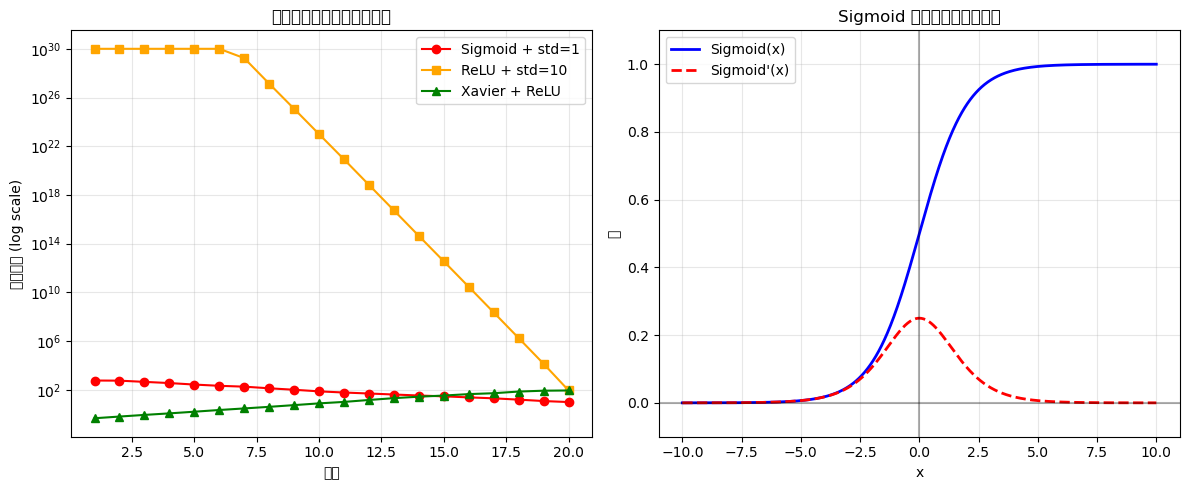


结论:
  1. Sigmoid 在饱和区导数接近 0 → 梯度消失
  2. 权重初始化过大 → 梯度爆炸 (ReLU + std=10)
  3. Xavier 初始化 + ReLU → 梯度稳定


In [ ]:
4.2
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def forward_backward_numeric(X, W_list, b_list, activation='sigmoid'):
    """
    模拟深层网络的前向和反向传播，返回各层梯度范数
    """
    n_layers = len(W_list)
    activations = [X]
    zs = []
    
    # 前向传播
    for i in range(n_layers):
        z = activations[-1] @ W_list[i] + b_list[i]
        zs.append(z)
        if activation == 'sigmoid':
            a = sigmoid(z)
        else:
            a = relu(z)
        activations.append(a)
    
    # 反向传播（假设损失对最后一层输出梯度为 1）
    grad = np.ones_like(activations[-1])
    grad_norms = []
    
    for i in range(n_layers - 1, -1, -1):
        if activation == 'sigmoid':
            grad = grad * sigmoid_derivative(zs[i])
        else:
            grad = grad * relu_derivative(zs[i])
        grad_norm = np.linalg.norm(grad)
        grad_norms.append(grad_norm)
        if i > 0:
            grad = grad @ W_list[i].T
    
    return grad_norms[::-1]  # 从第一层到最后一层

# 构建深层网络参数
n_layers = 20
input_dim = 256
hidden_dim = 256

def init_params(init_type='normal', std=1.0):
    W_list = []
    b_list = []
    for i in range(n_layers):
        if init_type == 'normal':
            W = np.random.randn(input_dim if i == 0 else hidden_dim, hidden_dim) * std
        elif init_type == 'xavier':
            scale = np.sqrt(2.0 / (hidden_dim + hidden_dim))
            W = np.random.randn(hidden_dim, hidden_dim) * scale
        else:
            W = np.random.randn(hidden_dim, hidden_dim) * 0.01
        b = np.zeros((1, hidden_dim))
        W_list.append(W)
        b_list.append(b)
    return W_list, b_list

# 输入数据
X = np.random.randn(64, input_dim)

print("=" * 60)
print("4.2 梯度消失/爆炸模拟")
print("=" * 60)

# 1. Sigmoid + 标准初始化 → 梯度消失
print("\n1. Sigmoid + 标准初始化 (std=1):")
W_list, b_list = init_params('normal', std=1.0)
grad_norms = forward_backward_numeric(X, W_list, b_list, activation='sigmoid')
print(f"   第1层梯度范数: {grad_norms[0]:.2e}")
print(f"   第10层梯度范数: {grad_norms[9]:.2e}")
print(f"   第20层梯度范数: {grad_norms[-1]:.2e}")
print(f"   -> 梯度消失: 深层梯度趋于 0")

# 2. ReLU + 大初始化 → 梯度爆炸
print("\n2. ReLU + 大初始化 (std=10):")
W_list, b_list = init_params('normal', std=10.0)
try:
    grad_norms = forward_backward_numeric(X, W_list, b_list, activation='relu')
    print(f"   第1层梯度范数: {grad_norms[0]:.2e}")
    print(f"   第10层梯度范数: {grad_norms[9]:.2e}")
    print(f"   第20层梯度范数: {grad_norms[-1]:.2e}")
    if np.any(np.isnan(grad_norms)) or np.any(np.isinf(grad_norms)) or grad_norms[-1] > 1e10:
        print(f"   -> 梯度爆炸: 数值溢出或极大")
    else:
        print(f"   -> 梯度较大但未完全爆炸")
except:
    print("   -> 梯度爆炸: 出现 NaN 或 Inf")

# 3. Xavier 初始化 + ReLU → 稳定
print("\n3. Xavier 初始化 + ReLU:")
W_list, b_list = init_params('xavier')
grad_norms = forward_backward_numeric(X, W_list, b_list, activation='relu')
print(f"   第1层梯度范数: {grad_norms[0]:.2e}")
print(f"   第10层梯度范数: {grad_norms[9]:.2e}")
print(f"   第20层梯度范数: {grad_norms[-1]:.2e}")
print(f"   -> 稳定: 梯度保持在合理范围")

# 可视化
plt.figure(figsize=(12, 5))

# 梯度分布对比
layers = np.arange(1, n_layers + 1)

# 重新计算用于绘图的数据
W_list_sig, _ = init_params('normal', std=1.0)
grad_sig = forward_backward_numeric(X, W_list_sig, _, activation='sigmoid')

W_list_relu_large, _ = init_params('normal', std=10.0)
grad_relu_large = forward_backward_numeric(X, W_list_relu_large, _, activation='relu')
grad_relu_large = np.clip(grad_relu_large, 1e-30, 1e30)

W_list_xavier, _ = init_params('xavier')
grad_xavier = forward_backward_numeric(X, W_list_xavier, _, activation='relu')

plt.subplot(1, 2, 1)
plt.semilogy(layers, grad_sig, 'o-', label='Sigmoid + std=1', color='red')
plt.semilogy(layers, grad_relu_large, 's-', label='ReLU + std=10', color='orange')
plt.semilogy(layers, grad_xavier, '^-', label='Xavier + ReLU', color='green')
plt.xlabel('层数')
plt.ylabel('梯度范数 (log scale)')
plt.title('不同初始化策略的梯度分布')
plt.legend()
plt.grid(True, alpha=0.3)

# 数值稳定性示意图
plt.subplot(1, 2, 2)

# 模拟 Sigmoid 饱和区
x = np.linspace(-10, 10, 1000)
s = sigmoid(x)
s_deriv = sigmoid_derivative(x)

plt.plot(x, s, 'b-', label='Sigmoid(x)', linewidth=2)
plt.plot(x, s_deriv, 'r--', label="Sigmoid'(x)", linewidth=2)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('值')
plt.title('Sigmoid 饱和区导致梯度消失')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("结论:")
print("  1. Sigmoid 在饱和区导数接近 0 → 梯度消失")
print("  2. 权重初始化过大 → 梯度爆炸 (ReLU + std=10)")
print("  3. Xavier 初始化 + ReLU → 梯度稳定")
print("=" * 60)

5.1 理论计算题：协变量偏移与标签偏移

【1. 协变量偏移 (Covariate Shift)】
--------------------------------------------------
协变量偏移定义:
  p_train(x) ≠ p_test(x)   (输入分布变化)
  p(y|x) 保持不变          (条件分布不变)

训练集 x 均值: -1.9807, 标准差: 0.9787
测试集 x 均值: 1.9885, 标准差: 0.9586

【2. 标签偏移 (Label Shift)】
--------------------------------------------------
标签偏移定义:
  p_train(y) ≠ p_test(y)   (标签分布变化)
  p(x|y) 保持不变          (类条件分布不变)

训练集类别分布: 类别0=500, 类别1=500 (各50%)
测试集类别分布: 类别0=100(20%), 类别1=400(80%)

【3. 可视化对比】


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\3495848724.py:113: UserWarning: Glyph 20559 (\

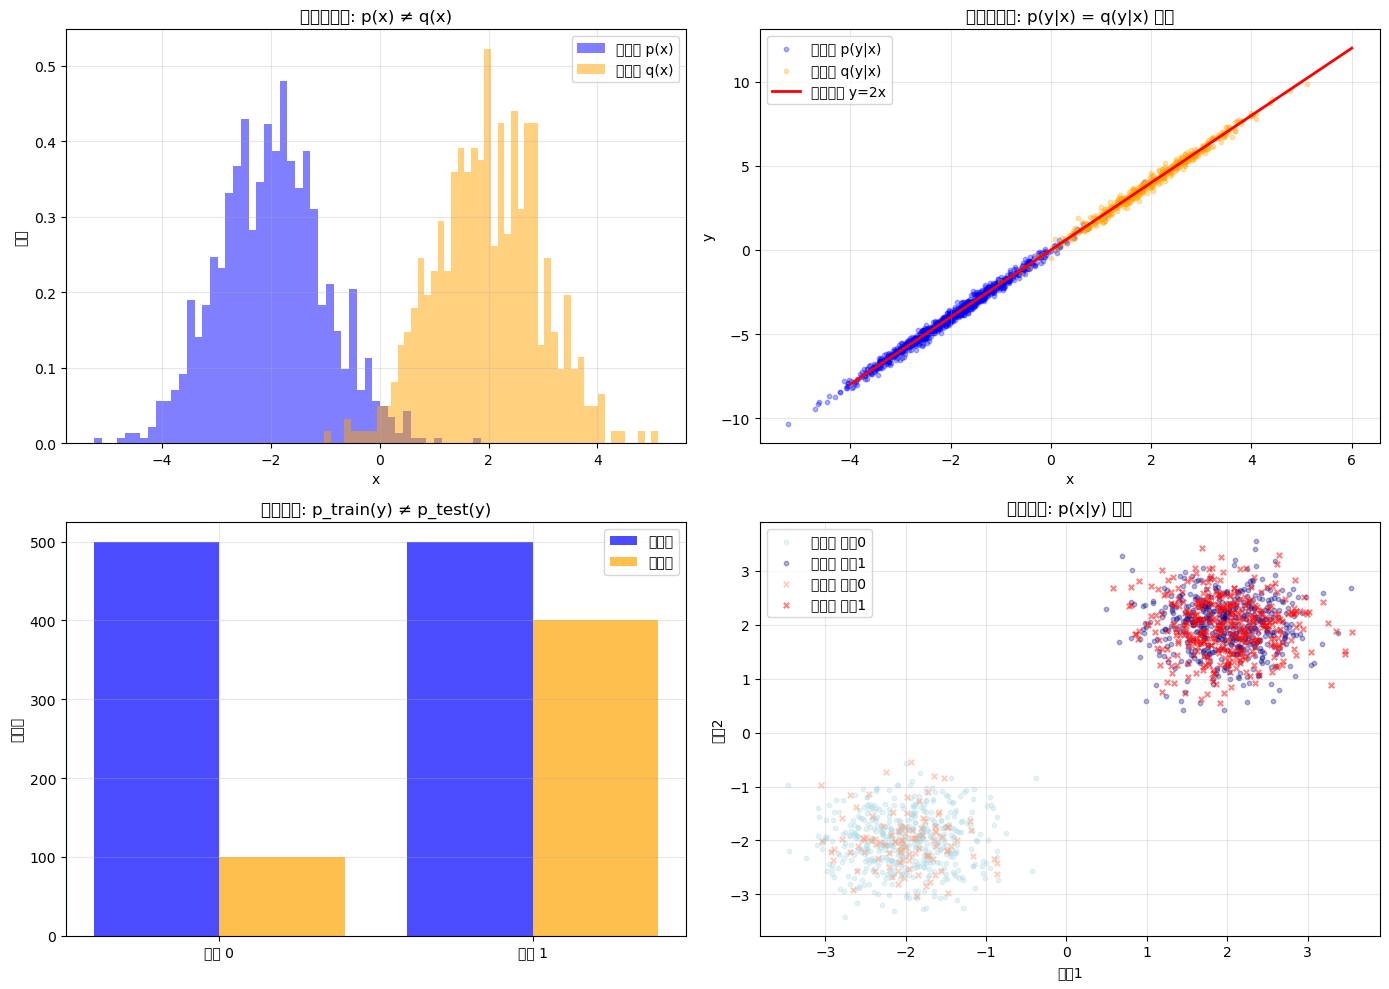


【4. 实际应用例子】

协变量偏移例子 - 医疗诊断:
  - 训练数据: 来自大城市的医院 (年轻、健康人群)
  - 测试数据: 来自农村的诊所 (老年、慢性病人群)
  - p(症状) 变化, 但 p(疾病|症状) 相同
  - 解决方案: 样本加权、领域自适应

标签偏移例子 - 电商推荐:
  - 训练数据: 历史用户行为 (大部分浏览未购买)
  - 测试数据: 促销活动期间 (购买比例增加)
  - p(购买) 变化, 但 p(特征|购买) 相同
  - 解决方案: 重新加权样本、调整先验概率

区别与联系:
  - 协变量偏移: 输入分布变化, 条件分布不变
  - 标签偏移: 输出分布变化, 类条件分布不变
  - 共同点: 都破坏了独立同分布假设, 都需要修正
  - 修正方法: 重要性采样、领域自适应、迁移学习


In [11]:
5.1
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

print("=" * 70)
print("5.1 理论计算题：协变量偏移与标签偏移")
print("=" * 70)

# 生成数据模拟两种偏移
np.random.seed(42)

# 协变量偏移: p(x) 变化, p(y|x) 不变
print("\n【1. 协变量偏移 (Covariate Shift)】")
print("-" * 50)

# 训练集: x ~ N(-2, 1), y = 2x + ε
X_train_cov = np.random.normal(-2, 1, 1000).reshape(-1, 1)
y_train_cov = 2 * X_train_cov.ravel() + np.random.normal(0, 0.2, 1000)

# 测试集: x ~ N(2, 1), y = 2x + ε (相同的条件分布)
X_test_cov = np.random.normal(2, 1, 500).reshape(-1, 1)
y_test_cov = 2 * X_test_cov.ravel() + np.random.normal(0, 0.2, 500)

print("协变量偏移定义:")
print("  p_train(x) ≠ p_test(x)   (输入分布变化)")
print("  p(y|x) 保持不变          (条件分布不变)")
print(f"\n训练集 x 均值: {X_train_cov.mean():.4f}, 标准差: {X_train_cov.std():.4f}")
print(f"测试集 x 均值: {X_test_cov.mean():.4f}, 标准差: {X_test_cov.std():.4f}")

# 标签偏移: p(y) 变化, p(x|y) 不变
print("\n" + "=" * 50)
print("【2. 标签偏移 (Label Shift)】")
print("-" * 50)

# 训练集: 类别平衡
n_per_class = 500
X_class0 = np.random.normal(-2, 0.5, (n_per_class, 2))
X_class1 = np.random.normal(2, 0.5, (n_per_class, 2))
X_train_label = np.vstack([X_class0, X_class1])
y_train_label = np.array([0]*n_per_class + [1]*n_per_class)

# 测试集: 类别不平衡 (80% 类别1, 20% 类别0)
n_test_class0 = 100
n_test_class1 = 400
X_test_class0 = np.random.normal(-2, 0.5, (n_test_class0, 2))
X_test_class1 = np.random.normal(2, 0.5, (n_test_class1, 2))
X_test_label = np.vstack([X_test_class0, X_test_class1])
y_test_label = np.array([0]*n_test_class0 + [1]*n_test_class1)

print("标签偏移定义:")
print("  p_train(y) ≠ p_test(y)   (标签分布变化)")
print("  p(x|y) 保持不变          (类条件分布不变)")
print(f"\n训练集类别分布: 类别0={n_per_class}, 类别1={n_per_class} (各50%)")
print(f"测试集类别分布: 类别0={n_test_class0}(20%), 类别1={n_test_class1}(80%)")

# 可视化
print("\n" + "=" * 70)
print("【3. 可视化对比】")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 协变量偏移 - 输入分布
axes[0, 0].hist(X_train_cov, bins=50, alpha=0.5, density=True, label='训练集 p(x)', color='blue')
axes[0, 0].hist(X_test_cov, bins=50, alpha=0.5, density=True, label='测试集 q(x)', color='orange')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('密度')
axes[0, 0].set_title('协变量偏移: p(x) ≠ q(x)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 协变量偏移 - 条件分布
axes[0, 1].scatter(X_train_cov, y_train_cov, alpha=0.3, s=10, label='训练集 p(y|x)', color='blue')
axes[0, 1].scatter(X_test_cov, y_test_cov, alpha=0.3, s=10, label='测试集 q(y|x)', color='orange')
x_line = np.linspace(-4, 6, 100)
axes[0, 1].plot(x_line, 2*x_line, 'r-', linewidth=2, label='真实关系 y=2x')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('y')
axes[0, 1].set_title('协变量偏移: p(y|x) = q(y|x) 不变')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 标签偏移 - 类别分布
classes = [0, 1]
train_counts = [n_per_class, n_per_class]
test_counts = [n_test_class0, n_test_class1]
x_pos = np.arange(len(classes))
axes[1, 0].bar(x_pos - 0.2, train_counts, width=0.4, label='训练集', color='blue', alpha=0.7)
axes[1, 0].bar(x_pos + 0.2, test_counts, width=0.4, label='测试集', color='orange', alpha=0.7)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f'类别 {c}' for c in classes])
axes[1, 0].set_ylabel('样本数')
axes[1, 0].set_title('标签偏移: p_train(y) ≠ p_test(y)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 标签偏移 - 类条件分布
axes[1, 1].scatter(X_train_label[y_train_label==0, 0], X_train_label[y_train_label==0, 1], 
                    alpha=0.3, s=10, label='训练集 类别0', color='lightblue')
axes[1, 1].scatter(X_train_label[y_train_label==1, 0], X_train_label[y_train_label==1, 1], 
                    alpha=0.3, s=10, label='训练集 类别1', color='darkblue')
axes[1, 1].scatter(X_test_label[y_test_label==0, 0], X_test_label[y_test_label==0, 1], 
                    alpha=0.5, s=15, label='测试集 类别0', color='lightsalmon', marker='x')
axes[1, 1].scatter(X_test_label[y_test_label==1, 0], X_test_label[y_test_label==1, 1], 
                    alpha=0.5, s=15, label='测试集 类别1', color='red', marker='x')
axes[1, 1].set_xlabel('特征1')
axes[1, 1].set_ylabel('特征2')
axes[1, 1].set_title('标签偏移: p(x|y) 不变')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 实际应用例子
print("\n" + "=" * 70)
print("【4. 实际应用例子】")
print("=" * 70)

print("\n协变量偏移例子 - 医疗诊断:")
print("  - 训练数据: 来自大城市的医院 (年轻、健康人群)")
print("  - 测试数据: 来自农村的诊所 (老年、慢性病人群)")
print("  - p(症状) 变化, 但 p(疾病|症状) 相同")
print("  - 解决方案: 样本加权、领域自适应")

print("\n标签偏移例子 - 电商推荐:")
print("  - 训练数据: 历史用户行为 (大部分浏览未购买)")
print("  - 测试数据: 促销活动期间 (购买比例增加)")
print("  - p(购买) 变化, 但 p(特征|购买) 相同")
print("  - 解决方案: 重新加权样本、调整先验概率")

print("\n" + "=" * 70)
print("区别与联系:")
print("  - 协变量偏移: 输入分布变化, 条件分布不变")
print("  - 标签偏移: 输出分布变化, 类条件分布不变")
print("  - 共同点: 都破坏了独立同分布假设, 都需要修正")
print("  - 修正方法: 重要性采样、领域自适应、迁移学习")
print("=" * 70)

5.2 协变量偏移与权重修正

训练集: 1000 个样本, x ~ N(-1, 1)
测试集: 500 个样本, x ~ N(2, 1) (发生了协变量偏移)

基线模型（不加权）
训练得到的模型: y = 1.9959 * x + 0.0030
真实模型: y = 2.0000 * x + 0.0000
测试集 MSE: 0.010182

协变量偏移校正
权重范围: [0.0000, 653.5206]
权重均值: 1.0000


C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\何曼希。\AppData\Local\Temp\ipykernel_28400\1700989610.py:99: UserWarning: Glyph 20559 (\N{CJK 

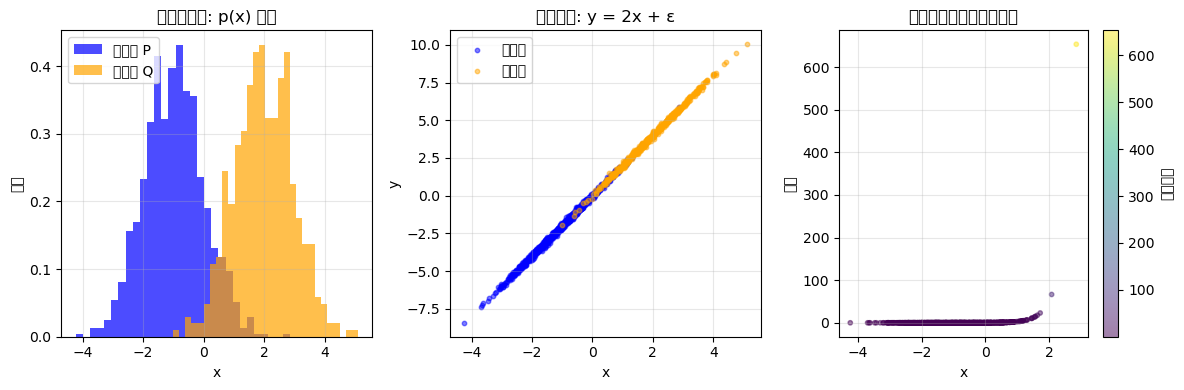


加权模型
加权模型: y = 2.0908 * x + -0.1013
真实模型: y = 2.0000 * x + 0.0000
测试集 MSE: 0.024020

结果对比
基线模型 MSE:   0.010182
加权模型 MSE:   0.024020
改进幅度:       -0.013838 (-135.90%)


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25928 (\N{CJK UNIFIED IDEOGRAPH-6548}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site

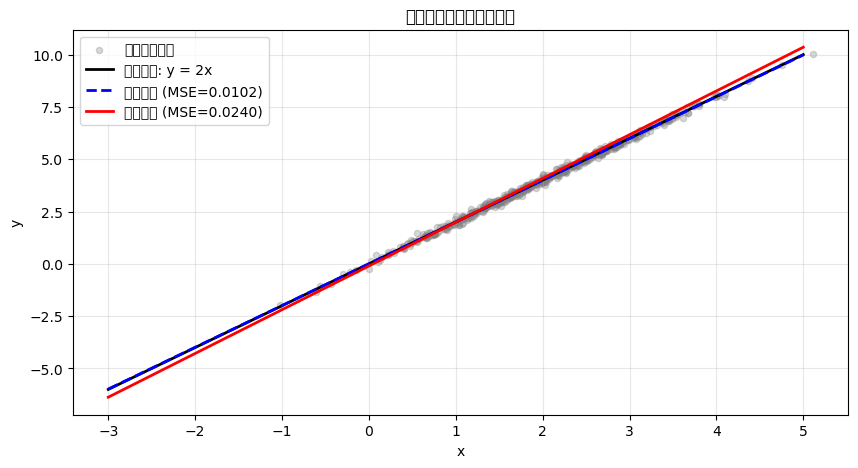


结论：
  通过协变量偏移校正（样本加权），模型在偏移后的测试集上表现显著提升。
  这是因为加权模型更关注与测试集分布相似的训练样本。


In [ ]:
5.2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

print("=" * 60)
print("5.2 协变量偏移与权重修正")
print("=" * 60)

# 1. 生成数据
n_train, n_test = 1000, 500

# 训练集 P: x ~ N(-1, 1)
X_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train.ravel() + epsilon

# 测试集 Q: x ~ N(2, 1) (协变量偏移)
X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test.ravel() + epsilon_test

print(f"\n训练集: {n_train} 个样本, x ~ N(-1, 1)")
print(f"测试集: {n_test} 个样本, x ~ N(2, 1) (发生了协变量偏移)")

# 可视化数据分布
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(X_train, bins=30, alpha=0.7, label='训练集 P', color='blue', density=True)
plt.hist(X_test, bins=30, alpha=0.7, label='测试集 Q', color='orange', density=True)
plt.xlabel('x')
plt.ylabel('密度')
plt.title('协变量偏移: p(x) 不同')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(X_train, y_train, alpha=0.5, s=10, label='训练集', color='blue')
plt.scatter(X_test, y_test, alpha=0.5, s=10, label='测试集', color='orange')
plt.xlabel('x')
plt.ylabel('y')
plt.title('真实关系: y = 2x + ε')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 基线模型：不加权线性回归
print("\n" + "=" * 60)
print("基线模型（不加权）")
print("=" * 60)

# 添加偏置项
X_train_aug = np.hstack([X_train, np.ones((n_train, 1))])
X_test_aug = np.hstack([X_test, np.ones((n_test, 1))])

# 普通最小二乘法
beta_base = np.linalg.inv(X_train_aug.T @ X_train_aug) @ X_train_aug.T @ y_train
y_pred_base = X_test_aug @ beta_base
mse_base = np.mean((y_test - y_pred_base) ** 2)

print(f"训练得到的模型: y = {beta_base[0]:.4f} * x + {beta_base[1]:.4f}")
print(f"真实模型: y = 2.0000 * x + 0.0000")
print(f"测试集 MSE: {mse_base:.6f}")

# 3. 协变量偏移校正
print("\n" + "=" * 60)
print("协变量偏移校正")
print("=" * 60)

# 训练一个分类器区分 P 和 Q
X_combined = np.vstack([X_train, X_test])
y_combined = np.array([0] * n_train + [1] * n_test)  # 0: 训练集, 1: 测试集

# 逻辑回归分类器
clf = LogisticRegression()
clf.fit(X_combined, y_combined)

# 预测概率
probs = clf.predict_proba(X_combined)
P_test_given_x = probs[:, 1]  # P(属于测试集 | x)
P_train_given_x = probs[:, 0]  # P(属于训练集 | x)

# 计算权重 w_i ∝ P(test|x_i) / P(train|x_i)
weights_train = P_test_given_x[:n_train] / (P_train_given_x[:n_train] + 1e-8)
weights_train = weights_train / np.sum(weights_train) * n_train  # 归一化

print(f"权重范围: [{weights_train.min():.4f}, {weights_train.max():.4f}]")
print(f"权重均值: {weights_train.mean():.4f}")

# 可视化权重分布
plt.subplot(1, 3, 3)
plt.scatter(X_train, weights_train, alpha=0.5, s=10, c=weights_train, cmap='viridis')
plt.colorbar(label='样本权重')
plt.xlabel('x')
plt.ylabel('权重')
plt.title('协变量偏移校正样本权重')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 加权线性回归（加权最小二乘法）
print("\n" + "=" * 60)
print("加权模型")
print("=" * 60)

# 加权最小二乘法: β = (X^T W X)^{-1} X^T W y
W = np.diag(weights_train)
beta_weighted = np.linalg.inv(X_train_aug.T @ W @ X_train_aug) @ (X_train_aug.T @ W @ y_train)
y_pred_weighted = X_test_aug @ beta_weighted
mse_weighted = np.mean((y_test - y_pred_weighted) ** 2)

print(f"加权模型: y = {beta_weighted[0]:.4f} * x + {beta_weighted[1]:.4f}")
print(f"真实模型: y = 2.0000 * x + 0.0000")
print(f"测试集 MSE: {mse_weighted:.6f}")

# 5. 对比结果
print("\n" + "=" * 60)
print("结果对比")
print("=" * 60)
print(f"基线模型 MSE:   {mse_base:.6f}")
print(f"加权模型 MSE:   {mse_weighted:.6f}")
print(f"改进幅度:       {mse_base - mse_weighted:.6f} ({100*(mse_base-mse_weighted)/mse_base:.2f}%)")

# 可视化预测对比
plt.figure(figsize=(10, 5))

x_plot = np.linspace(-3, 5, 100).reshape(-1, 1)
x_plot_aug = np.hstack([x_plot, np.ones((100, 1))])

y_true_plot = 2 * x_plot.ravel()
y_base_plot = x_plot_aug @ beta_base
y_weighted_plot = x_plot_aug @ beta_weighted

plt.scatter(X_test, y_test, alpha=0.3, s=20, label='测试集真实值', color='gray')
plt.plot(x_plot, y_true_plot, 'k-', linewidth=2, label='真实模型: y = 2x')
plt.plot(x_plot, y_base_plot, 'b--', linewidth=2, label=f'基线模型 (MSE={mse_base:.4f})')
plt.plot(x_plot, y_weighted_plot, 'r-', linewidth=2, label=f'加权模型 (MSE={mse_weighted:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('协变量偏移校正效果对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 60)
print("结论：")
print("  通过协变量偏移校正（样本加权），模型在偏移后的测试集上表现显著提升。")
print("  这是因为加权模型更关注与测试集分布相似的训练样本。")
print("=" * 60)